<a href="https://colab.research.google.com/github/EberHernandezBenitez/EDP/blob/main/Prueba_kolmogorov_Smirnov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tabulate
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Para nuestra prueba de Kolmogorov-Smirnov dada nuestra lista de 100 datos estableceremos las hipotesis nulas:
$$H_0:X_n \sim U(0,1)$$
$$H_a:X_n \not\sim U(0,1)$$
Ahora, vamos a organizarlos de menor a mayor y calcularemos el estadistico de prueba $D^+ $ y $D^-$ para $D=max(D^+,D^-)$
Y finalmente lo compararemos con el valor critico $d_{α n}$ y si $D<d_{\alpha n}$ no se rechaza $H_0$
Además, vamos a graficar los valores en el orden asendente y el esperado.

PRUEBA DE KOLMOGOROV-SMIRNOV
--------------------------------------------------
+-----+---------+-----------+-------+---------+---------+
|   i |      xi |   (i-1)/n |   i/n |      D+ |      D- |
|-----+---------+-----------+-------+---------+---------|
|   1 | 0.00121 |      0    |  0.01 | 0.00879 | 0.00121 |
|   2 | 0.03185 |      0.01 |  0.02 | 0.01185 | 0.02185 |
|   3 | 0.03272 |      0.02 |  0.03 | 0.00272 | 0.01272 |
|   4 | 0.0501  |      0.03 |  0.04 | 0.0101  | 0.0201  |
|   5 | 0.0523  |      0.04 |  0.05 | 0.0023  | 0.0123  |
|   6 | 0.05475 |      0.05 |  0.06 | 0.00525 | 0.00475 |
|   7 | 0.07281 |      0.06 |  0.07 | 0.00281 | 0.01281 |
|   8 | 0.08128 |      0.07 |  0.08 | 0.00128 | 0.01128 |
|   9 | 0.09133 |      0.08 |  0.09 | 0.00133 | 0.01133 |
|  10 | 0.09264 |      0.09 |  0.1  | 0.00736 | 0.00264 |
|  91 | 0.85903 |      0.9  |  0.91 | 0.05097 | 0.04097 |
|  92 | 0.87616 |      0.91 |  0.92 | 0.04384 | 0.03384 |
|  93 | 0.87855 |      0.92 |  0.93 | 0.05145 | 0.

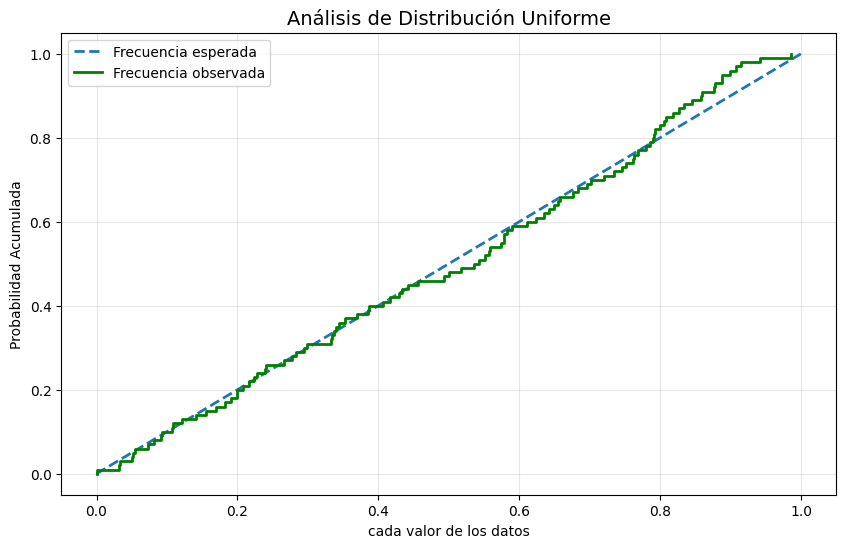

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ksone
from tabulate import tabulate

datos = [0.78961, 0.05230, 0.76086, 0.12079, 0.10699, 0.55877, 0.14151, 0.80548, 0.82654, 0.27738,
    0.65726, 0.29453, 0.20852, 0.79269, 0.89898, 0.98611, 0.57880, 0.84488, 0.42989, 0.34358,
    0.28269, 0.67621, 0.05010, 0.00121, 0.38618, 0.78059, 0.76910, 0.70119, 0.18284, 0.49962,
    0.79982, 0.45679, 0.68334, 0.55170, 0.58962, 0.21691, 0.10859, 0.33216, 0.87616, 0.69623,
    0.03185, 0.17028, 0.61168, 0.55743, 0.05475, 0.09264, 0.29931, 0.80861, 0.91512, 0.57410,
    0.83358, 0.76262, 0.26593, 0.51781, 0.85903, 0.03272, 0.24000, 0.65559, 0.43308, 0.38507,
    0.35286, 0.88809, 0.90829, 0.54325, 0.81772, 0.94187, 0.36982, 0.19904, 0.58244, 0.62400,
    0.09133, 0.85853, 0.41678, 0.88752, 0.33954, 0.23949, 0.19962, 0.53559, 0.33729, 0.33381,
    0.15506, 0.65002, 0.49383, 0.75103, 0.19147, 0.74579, 0.40644, 0.79113, 0.08128, 0.63453,
    0.22287, 0.07281, 0.73435, 0.64183, 0.22724, 0.44267, 0.72102, 0.57884, 0.87855, 0.78545]

n = len(datos)
alpha = 0.05
datos = np.sort(datos)
#Datos para calcular el estadistico
i = np.arange(1, n + 1)
i_n = i / n
i_minus_1_n = (i - 1) / n
d_mas = np.abs(i_n - datos)
d_menos = np.abs(datos - i_minus_1_n)

# Crear DataFrame
df = pd.DataFrame({
    'i': i,
    'xi': datos,
    '(i-1)/n': i_minus_1_n,
    'i/n': i_n,
    'D+': d_mas,
    'D-': d_menos
})

# Estadístico D
D_max = max(df['D+'].max(), df['D-'].max())
d_critico = ksone.ppf(1 - alpha/2, n)

print(f"PRUEBA DE KOLMOGOROV-SMIRNOV")
print("-" * 50)
tabla_resumen = pd.concat([df.head(10), df.tail(10)])
print(tabulate(tabla_resumen, headers='keys', tablefmt='psql', showindex=False))

print(f"\nEstadístico D calculado: {D_max:.5f}")
print(f"Nivel de significancia establecido: {alpha}")
print(f"Valor crítico de tabla d(α,n): {d_critico:.5f}")

if D_max < d_critico:
    print(" No se rechaza Ho. Los datos siguen una distribución Uniforme U(0,1).")
else:
    print(" Se rechaza Ho. Los datos NO son Uniformes.")

plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label='Frecuencia esperada')
plt.step(np.concatenate(([0], datos)), np.concatenate(([0], i_n)),
         where='post', color='green', linewidth=2, label='Frecuencia observada')
plt.title(f'Análisis de Distribución Uniforme', fontsize=14)
plt.xlabel('cada valor de los datos', fontsize=10)
plt.ylabel('Probabilidad Acumulada', fontsize=10)
plt.legend()
plt.grid(alpha=0.3)
plt.show()